mbient imu format saves it in two files, accerometer and gyroscope
accelerometer header: epoc (ms),timestamp (-0400),elapsed (s),x-axis (g),y-axis (g),z-axis (g)
gyroscope header: epoc (ms),timestamp (-0400),elapsed (s),x-axis (deg/s),y-axis (deg/s),z-axis (deg/s)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

In [5]:
# ---- UPDATE THESE PATHS ----
ACCEL_PATH = '/Volumes/disko!/HomeStretch/HomeStretchRepo/mbientcode/mbientdata/HomeStretch_2026-03-28T00.01.25.101_CD13451D4A6E_Accelerometer.csv'
GYRO_PATH  = '/Volumes/disko!/HomeStretch/HomeStretchRepo/mbientcode/mbientdata/HomeStretch_2026-03-28T00.01.25.101_CD13451D4A6_Gyroscope.csv'

ACCEL_PATH = "/Volumes/disko!/HomeStretch/HomeStretchRepo/mbientcode/mbientdata/HomeStretch_2026-03-28T00.03.05.270_CD13451D4A6E_Accelerometer.csv"
GYRO_PATH = "/Volumes/disko!/HomeStretch/HomeStretchRepo/mbientcode/mbientdata/HomeStretch_2026-03-28T00.03.05.270_CD13451D4A6E_Gyroscope.csv"
# ----------------------------

accel = pd.read_csv(ACCEL_PATH)
gyro  = pd.read_csv(GYRO_PATH)

accel.columns = ['epoc_ms', 'timestamp', 'elapsed_s', 'ax', 'ay', 'az']
gyro.columns  = ['epoc_ms', 'timestamp', 'elapsed_s', 'gx', 'gy', 'gz']

print('Accel shape:', accel.shape)
print('Gyro shape: ', gyro.shape)
accel.head(3)

Accel shape: (3915, 6)
Gyro shape:  (3913, 6)


,epoc_ms,timestamp,elapsed_s,ax,ay,az
0,1774670585270,2026-03-28T00.03.05.270,0.000,0.412,-0.910,-0.132
1,1774670585278,2026-03-28T00.03.05.278,0.008,0.405,-0.917,-0.135
2,1774670585289,2026-03-28T00.03.05.289,0.019,0.392,-0.918,-0.138


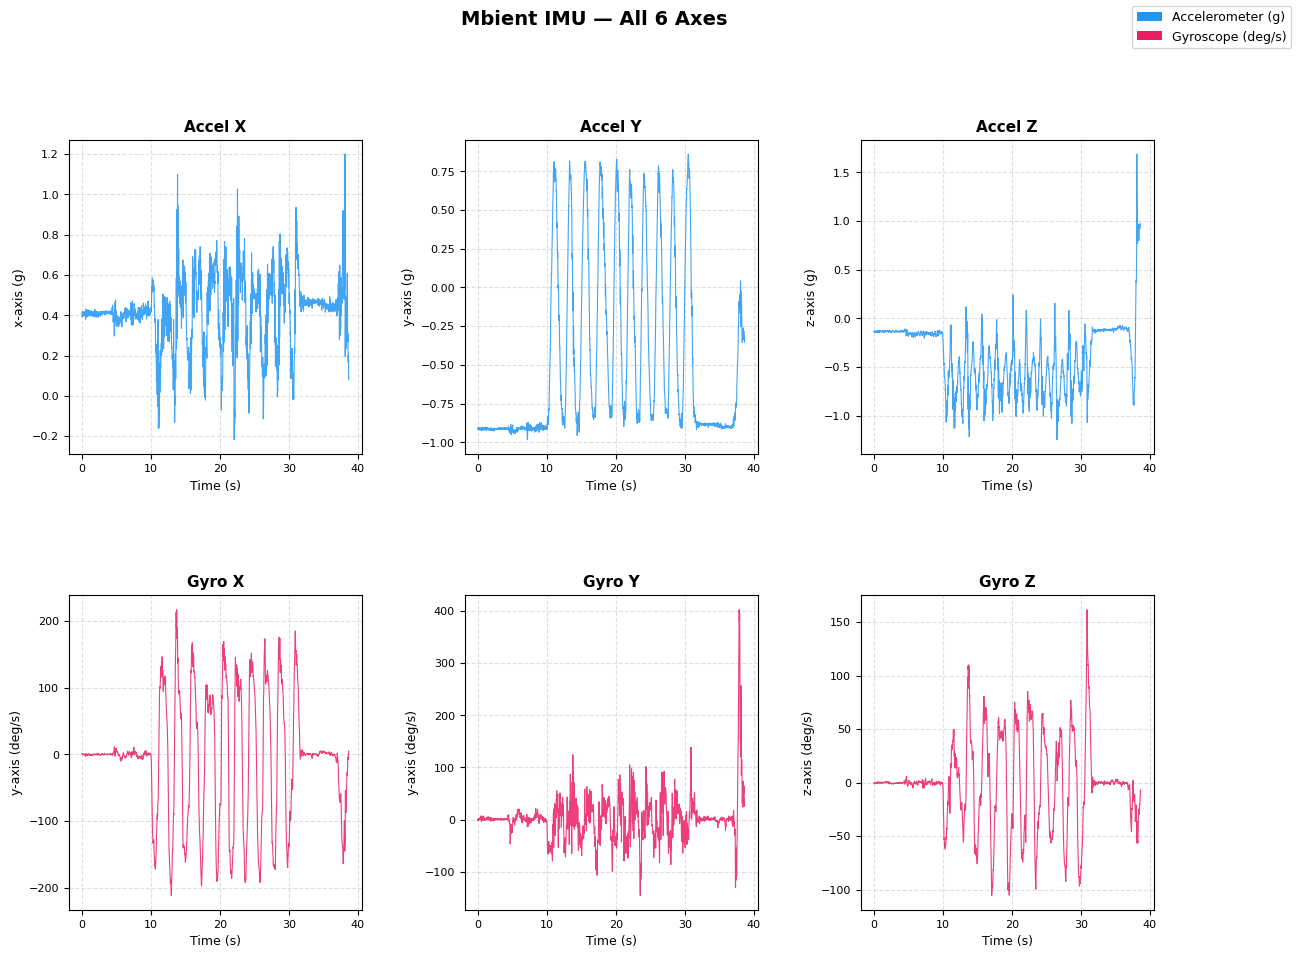

In [6]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ACCEL_COLOR = '#2196F3'
GYRO_COLOR  = '#E91E63'
ALPHA = 0.85

accel_axes = [
    ('ax', 'Accel X', 'x-axis (g)'),
    ('ay', 'Accel Y', 'y-axis (g)'),
    ('az', 'Accel Z', 'z-axis (g)'),
]
for col_idx, (col, title, ylabel) in enumerate(accel_axes):
    ax = fig.add_subplot(gs[0, col_idx])
    ax.plot(accel['elapsed_s'], accel[col], color=ACCEL_COLOR, lw=0.8, alpha=ALPHA)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Time (s)', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=8)

gyro_axes = [
    ('gx', 'Gyro X', 'y-axis (deg/s)'),
    ('gy', 'Gyro Y', 'y-axis (deg/s)'),
    ('gz', 'Gyro Z', 'z-axis (deg/s)'),
]
for col_idx, (col, title, ylabel) in enumerate(gyro_axes):
    ax = fig.add_subplot(gs[1, col_idx])
    ax.plot(gyro['elapsed_s'], gyro[col], color=GYRO_COLOR, lw=0.8, alpha=ALPHA)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Time (s)', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=8)

fig.suptitle('Mbient IMU — All 6 Axes', fontsize=14, fontweight='bold', y=1.01)
fig.legend(
    handles=[Patch(facecolor=ACCEL_COLOR, label='Accelerometer (g)'),
             Patch(facecolor=GYRO_COLOR,  label='Gyroscope (deg/s)')],
    loc='upper right', fontsize=9
)

plt.show()

# FILETERING

In [7]:
from scipy.signal import butter, filtfilt

def highpass(x, Fs, cutoff_hz, order=2):
    nyq = 0.5 * Fs
    b, a = butter(order, cutoff_hz / nyq, btype='high')
    return filtfilt(b, a, x)

def lowpass(x, Fs, cutoff_hz, order=2):
    nyq = 0.5 * Fs
    b, a = butter(order, cutoff_hz / nyq, btype='low')
    return filtfilt(b, a, x)

Fs = 1 / accel['elapsed_s'].diff().median()

# Remove gravity offset then bandpass
ay_raw = accel['ay'].values
ay_filtered = lowpass(ay_raw, Fs, cutoff_hz=5, order=2)
ay_filtered = highpass(ay_filtered, Fs, cutoff_hz=0.1, order=2)

In [8]:
import numpy as np

DEG2RAD = np.pi / 180

gx = gyro['gx'].values * DEG2RAD
gy = gyro['gy'].values * DEG2RAD
gz = gyro['gz'].values * DEG2RAD
gyro_mag = np.sqrt(gx**2 + gy**2 + gz**2)

Fs_gyro = 1 / gyro['elapsed_s'].diff().median()
gyro_filtered = lowpass(gyro_mag, Fs_gyro, cutoff_hz=10, order=2)
gyro_filtered = highpass(gyro_filtered, Fs_gyro, cutoff_hz=0.1, order=2)

Detected reps: 10
  Rep 1: 11.11s → 13.36s  (2.25s duration)
  Rep 2: 13.36s → 15.57s  (2.21s duration)
  Rep 3: 15.57s → 17.83s  (2.26s duration)
  Rep 4: 17.83s → 20.16s  (2.33s duration)
  Rep 5: 20.16s → 22.13s  (1.96s duration)
  Rep 6: 22.13s → 24.16s  (2.03s duration)
  Rep 7: 24.16s → 26.25s  (2.10s duration)
  Rep 8: 26.25s → 28.30s  (2.04s duration)
  Rep 9: 28.30s → 30.52s  (2.22s duration)
  Rep 10: 30.52s → 38.01s  (7.49s duration)


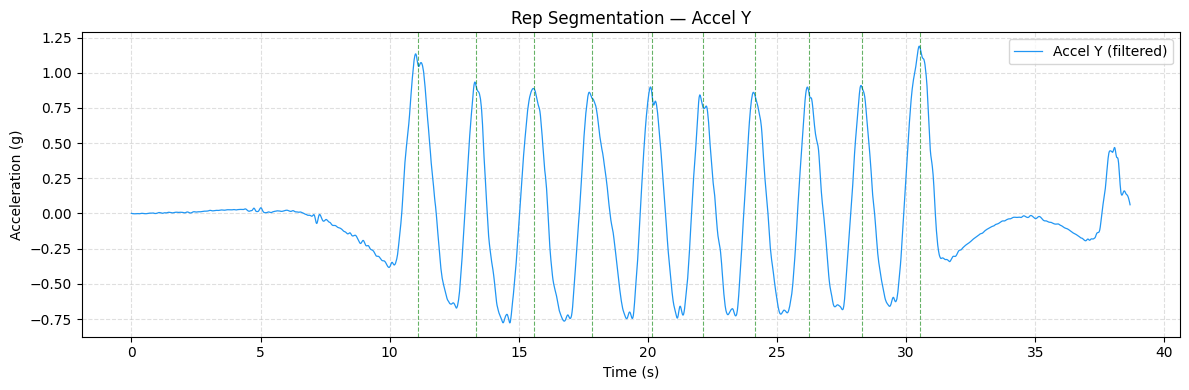

In [13]:
from scipy.signal import find_peaks

def segment_rep_mbient(signal, time, Fs):
    signal = lowpass(signal, Fs, 1, order=2)
    signal = highpass(signal, Fs, cutoff_hz=0.1, order=2)
    peaks, _ = find_peaks(signal, prominence=0.3, distance=int(Fs * 1.0))
    rep_times = []
    for i in range(len(peaks) - 1):
        rep_times.append((time[peaks[i]], time[peaks[i+1]]))
    return rep_times, len(rep_times)

time_accel = accel['elapsed_s'].values
rep_times, n_reps = segment_rep_mbient(ay_filtered, time_accel, Fs)

print(f'Detected reps: {n_reps}')
for i, (t_start, t_end) in enumerate(rep_times):
    print(f'  Rep {i+1}: {t_start:.2f}s → {t_end:.2f}s  ({t_end - t_start:.2f}s duration)')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_accel, ay_filtered, color='#2196F3', lw=0.9, label='Accel Y (filtered)')

for i, (t_start, t_end) in enumerate(rep_times):
    # ax.axvspan(t_start, t_end, alpha=0.15, color='green', label='Rep' if i == 0 else '')
    ax.axvline(t_start, color='green', lw=0.8, linestyle='--', alpha=0.6)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Acceleration (g)')
ax.set_title('Rep Segmentation — Accel Y')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

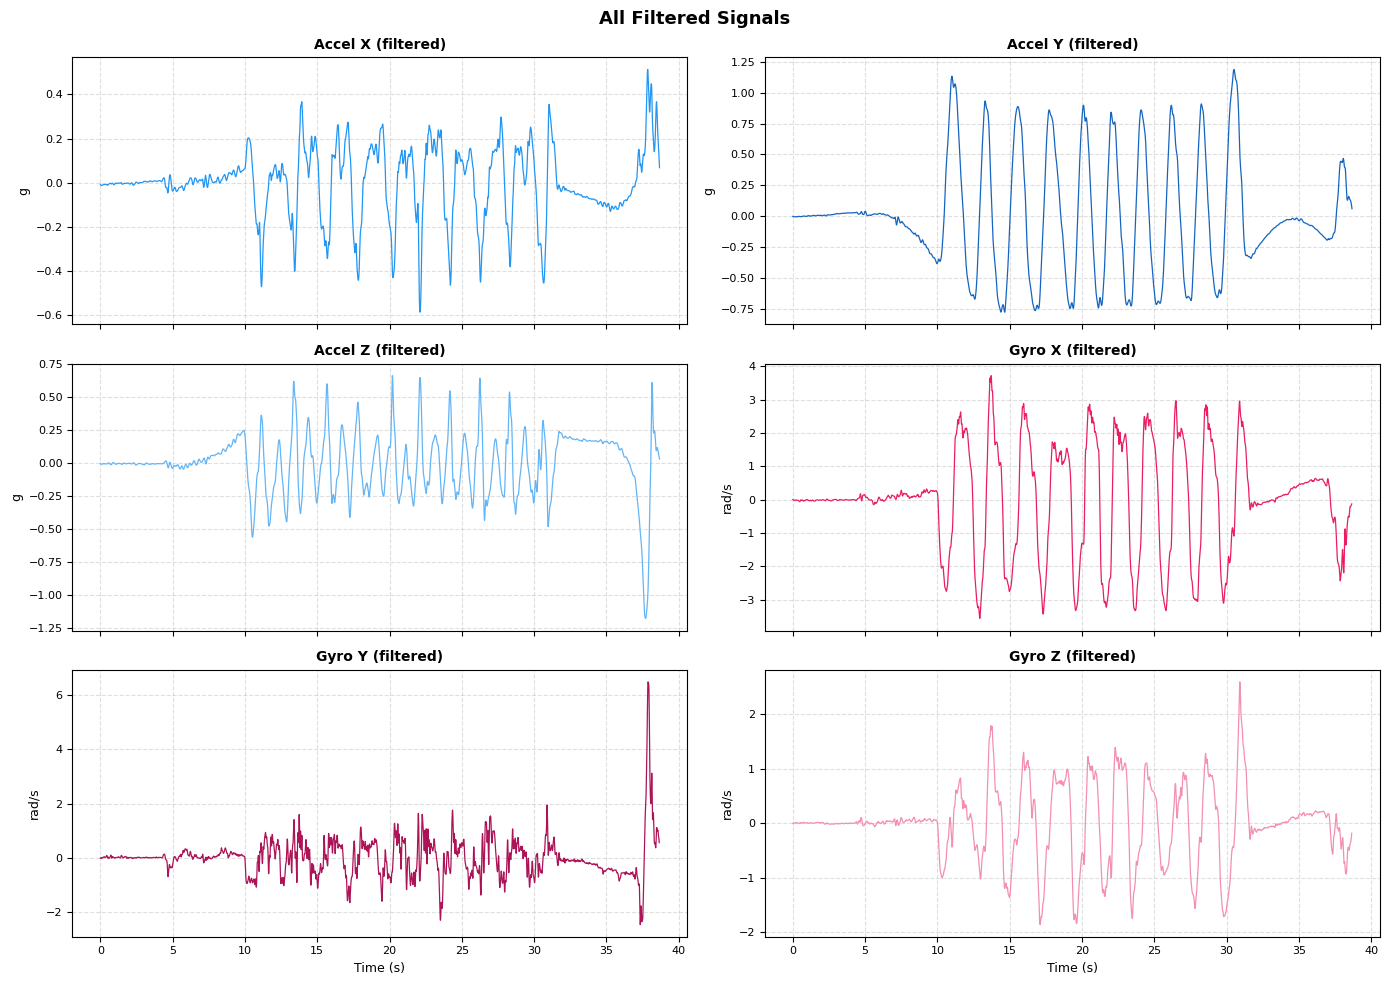

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
fig.suptitle('All Filtered Signals', fontsize=13, fontweight='bold')

accel_signals = [
    (ay_filtered, 'Accel Y (filtered)', 'g', '#2196F3'),
]

# Filter each accel axis
ax_filtered = lowpass(highpass(accel['ax'].values, Fs, 0.1), Fs, 5)
ay_filt     = lowpass(highpass(accel['ay'].values, Fs, 0.1), Fs, 5)
az_filtered = lowpass(highpass(accel['az'].values, Fs, 0.1), Fs, 5)

gx_filt = lowpass(highpass(gx, Fs_gyro, 0.1), Fs_gyro, 10)
gy_filt = lowpass(highpass(gy, Fs_gyro, 0.1), Fs_gyro, 10)
gz_filt = lowpass(highpass(gz, Fs_gyro, 0.1), Fs_gyro, 10)

signals = [
    (time_accel, ax_filtered, 'Accel X (filtered)', 'g'),
    (time_accel, ay_filt,     'Accel Y (filtered)', 'g'),
    (time_accel, az_filtered, 'Accel Z (filtered)', 'g'),
    (gyro['elapsed_s'].values, gx_filt, 'Gyro X (filtered)', 'rad/s'),
    (gyro['elapsed_s'].values, gy_filt, 'Gyro Y (filtered)', 'rad/s'),
    (gyro['elapsed_s'].values, gz_filt, 'Gyro Z (filtered)', 'rad/s'),
]

colors = ['#2196F3', '#1565C0', '#64B5F6', '#E91E63', '#AD1457', '#F48FB1']

for ax, (t, sig, title, unit), color in zip(axes.flat, signals, colors):
    ax.plot(t, sig, color=color, lw=0.9)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel(unit, fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=8)

for ax in axes[2]:
    ax.set_xlabel('Time (s)', fontsize=9)

plt.tight_layout()
plt.show()

# building lightweight ml model

In [15]:
import os
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib

In [30]:
def highpass(x, Fs, cutoff_hz, order=2):
    nyq = 0.5 * Fs
    b, a = butter(order, cutoff_hz / nyq, btype='high')
    return filtfilt(b, a, x)

def lowpass(x, Fs, cutoff_hz, order=2):
    nyq = 0.5 * Fs
    b, a = butter(order, cutoff_hz / nyq, btype='low')
    return filtfilt(b, a, x)

def segment_reps(signal, time, Fs):
    sig = lowpass(signal, Fs, 1, order=2)
    sig = highpass(sig, Fs, 0.1, order=2)
    peaks, _ = find_peaks(sig, prominence=0.05, distance=Fs*1.0)
    rep_segments = []
    for i in range(len(peaks) - 1):
        t_start, t_end = time[peaks[i]], time[peaks[i+1]]
        mask = (time >= t_start) & (time <= t_end)
        rep_segments.append({
            'signal': signal[mask],
            'time':   time[mask],
            't_start': t_start,
            't_end':   t_end,
        })
    return rep_segments

def compute_snr_db(signal, Fs):
    movement = highpass(lowpass(signal, Fs, 2), Fs, 0.1)
    noise    = highpass(signal, Fs, 3)
    rms_s = np.sqrt(np.mean(movement**2))
    rms_n = np.sqrt(np.mean(noise**2))
    if rms_n == 0:
        return np.inf
    return 20 * np.log10(rms_s / rms_n)

def compute_tremor_energy_ratio(signal, Fs):
    signal = signal - np.mean(signal)
    freqs  = np.fft.rfftfreq(len(signal), d=1/Fs)
    power  = np.abs(np.fft.rfft(signal))**2
    move_p   = np.sum(power[(freqs >= 0.1) & (freqs <= 2)])
    tremor_p = np.sum(power[(freqs >= 3)   & (freqs <= 8)])
    if move_p == 0:
        return np.inf
    return tremor_p / move_p

def extract_rep_features(rep_signal, rep_time, Fs, all_peak_amps):
    sig = rep_signal
    t   = rep_time

    duration = t[-1] - t[0]

    peak_amp = np.max(sig) - np.min(sig)
    norm_amp = peak_amp / np.mean(all_peak_amps) if np.mean(all_peak_amps) > 0 else 0

    peak_idx  = np.argmax(sig)
    rise_time = t[peak_idx] - t[0]
    fall_time = t[-1] - t[peak_idx]
    # Cap symmetry instead of returning inf
    symmetry  = rise_time / fall_time if fall_time > 1e-6 else rise_time / 1e-6
    symmetry  = np.clip(symmetry, 0, 10)  # cap at 10 so outliers don't dominate

    zero_crossings = np.where(np.diff(np.sign(sig)))[0]
    zcr = len(zero_crossings) / duration if duration > 0 else 0

    freqs    = np.fft.rfftfreq(len(sig), d=1/Fs)
    power    = np.abs(np.fft.rfft(sig))**2
    dom_freq = freqs[np.argmax(power)] if len(power) > 0 else 0

    snr_db       = compute_snr_db(sig, Fs)
    tremor_ratio = compute_tremor_energy_ratio(sig, Fs)
    log_tremor   = np.log10(tremor_ratio + 1)

    return {
        'duration':   duration,
        'norm_amp':   norm_amp,
        'symmetry':   symmetry,
        'zcr':        zcr,
        'dom_freq':   dom_freq,
        'snr_db':     snr_db,
        'log_tremor': log_tremor,
    }

In [31]:
DATA_ROOT = '/Volumes/disko!/HomeStretch/HomeStretchRepo/Data/Trimmed'

records = []

for label in ['Typical', 'Atypical']:
    folder = os.path.join(DATA_ROOT, label)
    if not os.path.exists(folder):
        print(f'Folder not found: {folder}')
        continue

    for fname in os.listdir(folder):
        if not fname.endswith('.csv'):
            continue

        fpath = os.path.join(folder, fname)
        try:
            df = pd.read_csv(fpath)
            time = df['seconds_elapsed'].values
            Fs   = 1 / np.mean(np.diff(time))
            sig  = df['gravityX'].values

            # Normalize per session
            sig = (sig - np.mean(sig)) / (np.std(sig) + 1e-8)

            rep_segments = segment_reps(sig, time, Fs)
            if len(rep_segments) == 0:
                print(f'No reps found: {fname}')
                continue

            # Compute all peak amps for normalization within session
            all_peak_amps = [np.max(r['signal']) - np.min(r['signal']) for r in rep_segments]

            for i, rep in enumerate(rep_segments):
                if len(rep['signal']) < 10:
                    continue
                feats = extract_rep_features(rep['signal'], rep['time'], Fs, all_peak_amps)
                feats['label']    = label
                feats['file']     = fname
                feats['rep_idx']  = i
                records.append(feats)

        except Exception as e:
            print(f'Error processing {fname}: {e}')

df_features = pd.DataFrame(records)
print(f'Total reps extracted: {len(df_features)}')
print(df_features['label'].value_counts())
df_features.head()

Total reps extracted: 351
label
Typical     255
Atypical     96
Name: count, dtype: int64


,duration,norm_amp,symmetry,zcr,dom_freq,snr_db,log_tremor,label,file,rep_idx
0,2.276996,1.014588,10.000000,0.878350,0.437246,45.270389,0.000029,Typical,Trimmed_001_BicepCurl_L_T.csv,0
1,2.106481,1.004890,10.000000,0.949451,0.472474,45.374793,0.000010,Typical,Trimmed_001_BicepCurl_L_T.csv,1
2,2.196767,1.025217,10.000000,0.910429,0.453146,46.315029,0.000015,Typical,Trimmed_001_BicepCurl_L_T.csv,2
3,2.527789,1.022457,0.003984,0.791205,0.394040,47.748266,0.000014,Typical,Trimmed_001_BicepCurl_L_T.csv,3
4,2.166679,1.004088,0.000000,0.923072,0.459410,47.333365,0.000013,Typical,Trimmed_001_BicepCurl_L_T.csv,4


In [61]:
FEATURE_COLS = ['duration', 'norm_amp', 'dom_freq', 'log_tremor']

# Check where infs are coming from
print("Inf counts per feature:")
print(np.isinf(df_features[FEATURE_COLS]).sum())

# Replace inf/-inf with NaN then drop
df_clean = df_features.copy()
df_clean[FEATURE_COLS] = df_clean[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)

print(f'\nRows before dropping NaN: {len(df_clean)}')
df_clean = df_clean.dropna(subset=FEATURE_COLS)
print(f'Rows after dropping NaN:  {len(df_clean)}')

# Train only on typical reps
df_typical = df_clean[df_clean['label'] == 'Typical'][FEATURE_COLS]

scaler = StandardScaler()
X_train = scaler.fit_transform(df_typical)

iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_forest.fit(X_train)

# Score everything
X_all = scaler.transform(df_clean[FEATURE_COLS])
df_clean['anomaly_score'] = iso_forest.decision_function(X_all)
df_clean['predicted']     = iso_forest.predict(X_all)

# Eval
from sklearn.metrics import classification_report
y_true = (df_clean['label'] == 'Atypical').astype(int)
y_pred = (df_clean['predicted'] == -1).astype(int)
print(classification_report(y_true, y_pred, target_names=['Typical', 'Atypical']))

joblib.dump(iso_forest, 'isolation_forest.pkl')
joblib.dump(scaler,     'scaler.pkl')
print('Saved isolation_forest.pkl and scaler.pkl')

Inf counts per feature:
duration      0
norm_amp      0
dom_freq      0
log_tremor    0
dtype: int64

Rows before dropping NaN: 351
Rows after dropping NaN:  351
              precision    recall  f1-score   support

     Typical       0.91      0.95      0.93       255
    Atypical       0.85      0.76      0.80        96

    accuracy                           0.90       351
   macro avg       0.88      0.85      0.87       351
weighted avg       0.90      0.90      0.90       351

Saved isolation_forest.pkl and scaler.pkl


In [84]:
DEG2RAD = np.pi / 180

ACCEL_PATH = "/Volumes/disko!/HomeStretch/HomeStretchRepo/mbientcode/mbientdata/Typical_Accelerometer.csv"
GYRO_PATH = "/Volumes/disko!/HomeStretch/HomeStretchRepo/mbientcode/mbientdata/Typical_Gyroscope.csv"

# ACCEL_PATH = "/Volumes/disko!/HomeStretch/HomeStretchRepo/mbientcode/mbientdata/left_atypical_Accelerometer.csv"
#GYRO_PATH = "/Volumes/disko!/HomeStretch/HomeStretchRepo/mbientcode/mbientdata/left_atypical_Gyroscope.csv"


accel = pd.read_csv(ACCEL_PATH)
gyro  = pd.read_csv(GYRO_PATH)

accel.columns = ['epoc_ms', 'timestamp', 'elapsed_s', 'ax', 'ay', 'az']
gyro.columns  = ['epoc_ms', 'timestamp', 'elapsed_s', 'gx', 'gy', 'gz']

# Convert gyro to rad/s
gyro['gx'] = gyro['gx'] * DEG2RAD
gyro['gy'] = gyro['gy'] * DEG2RAD
gyro['gz'] = gyro['gz'] * DEG2RAD

Fs = 1 / accel['elapsed_s'].diff().median()

# Use Accel Y, normalize per session (same as Apple Watch pipeline)
time_mbient = accel['elapsed_s'].values
sig_mbient  = accel['ay'].values
sig_mbient  = (sig_mbient - np.mean(sig_mbient)) / (np.std(sig_mbient) + 1e-8)

In [85]:
def segment_rep_mbient(signal, time, Fs):
    sig = lowpass(signal, Fs, 1, order=2)
    sig = highpass(sig, Fs, 0.1, order=2)
    
    # Find troughs (valleys) instead of peaks — rep boundaries are at rest position
    troughs, _ = find_peaks(sig, prominence=0.3, distance=int(Fs * 1.0))
    
    rep_segments = []
    for i in range(len(troughs) - 1):
        t_start, t_end = time[troughs[i]], time[troughs[i+1]]
        mask = (time >= t_start) & (time <= t_end)
        rep_segments.append({
            'signal':  signal[mask],
            'time':    time[mask],
            't_start': t_start,
            't_end':   t_end,
        })
    return rep_segments


rep_segments = segment_rep_mbient(sig_mbient, time_mbient, Fs)
print(f'Reps detected: {len(rep_segments)}')

if len(rep_segments) == 0:
    print('No reps found — try adjusting prominence in segment_reps()')
else:
    all_peak_amps = [np.max(r['signal']) - np.min(r['signal']) for r in rep_segments]

    records_mbient = []
    for i, rep in enumerate(rep_segments):
        if len(rep['signal']) < 10:
            continue
        feats = extract_rep_features(rep['signal'], rep['time'], Fs, all_peak_amps)
        feats['rep_idx'] = i
        records_mbient.append(feats)

    df_mbient = pd.DataFrame(records_mbient)
    print(df_mbient[FEATURE_COLS])

Reps detected: 11
    duration  norm_amp  dom_freq  log_tremor
0      1.876  1.053613  0.523560    0.002073
1      1.749  1.084932  0.561798    0.003918
2      1.987  0.894064  0.495050    0.001315
3      2.034  1.028203  0.483092    0.002495
4      2.461  1.072522  0.400000    0.001467
5      2.697  1.034112  0.364964    0.001491
6      2.322  0.928928  0.423729    0.001082
7      2.174  1.020521  0.452489    0.001110
8      2.015  1.035885  0.487805    0.001818
9      1.828  0.954338  0.537634    0.001489
10     2.578  0.892882  0.381679    0.005102


In [88]:
iso_forest = joblib.load('isolation_forest.pkl')
scaler     = joblib.load('scaler.pkl')

THRESHOLD = -0.19  # tuned for Mbient sensor

df_mbient[FEATURE_COLS] = df_mbient[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
df_mbient = df_mbient.dropna(subset=FEATURE_COLS)

X_mbient = scaler.transform(df_mbient[FEATURE_COLS])
df_mbient['anomaly_score'] = iso_forest.decision_function(X_mbient)
df_mbient['predicted']     = np.where(df_mbient['anomaly_score'] > THRESHOLD, 1, -1)

print(df_mbient[['rep_idx', 'anomaly_score', 'predicted']])
print('\nSummary:')
print(df_mbient['predicted'].value_counts().rename({1: 'Typical', -1: 'Atypical'}))

    rep_idx  anomaly_score  predicted
0         0      -0.158653          1
1         1      -0.195720         -1
2         2      -0.171895          1
3         3      -0.132763          1
4         4      -0.133034          1
5         5      -0.091540          1
6         6      -0.098914          1
7         7      -0.069293          1
8         8      -0.134703          1
9         9      -0.152929          1
10       10      -0.188495          1

Summary:
predicted
Typical     10
Atypical     1
Name: count, dtype: int64


In [87]:
# Tune threshold
threshold = -0.19    # tweak this: try -0.10, -0.05

df_mbient['predicted_custom'] = np.where(df_mbient['anomaly_score'] > threshold, 1, -1)

print(df_mbient[['rep_idx', 'anomaly_score', 'predicted_custom']])
print('\nSummary:')
print(df_mbient['predicted_custom'].value_counts().rename({1: 'Typical', -1: 'Atypical'}))

    rep_idx  anomaly_score  predicted_custom
0         0      -0.158653                 1
1         1      -0.195720                -1
2         2      -0.171895                 1
3         3      -0.132763                 1
4         4      -0.133034                 1
5         5      -0.091540                 1
6         6      -0.098914                 1
7         7      -0.069293                 1
8         8      -0.134703                 1
9         9      -0.152929                 1
10       10      -0.188495                 1

Summary:
predicted_custom
Typical     10
Atypical     1
Name: count, dtype: int64


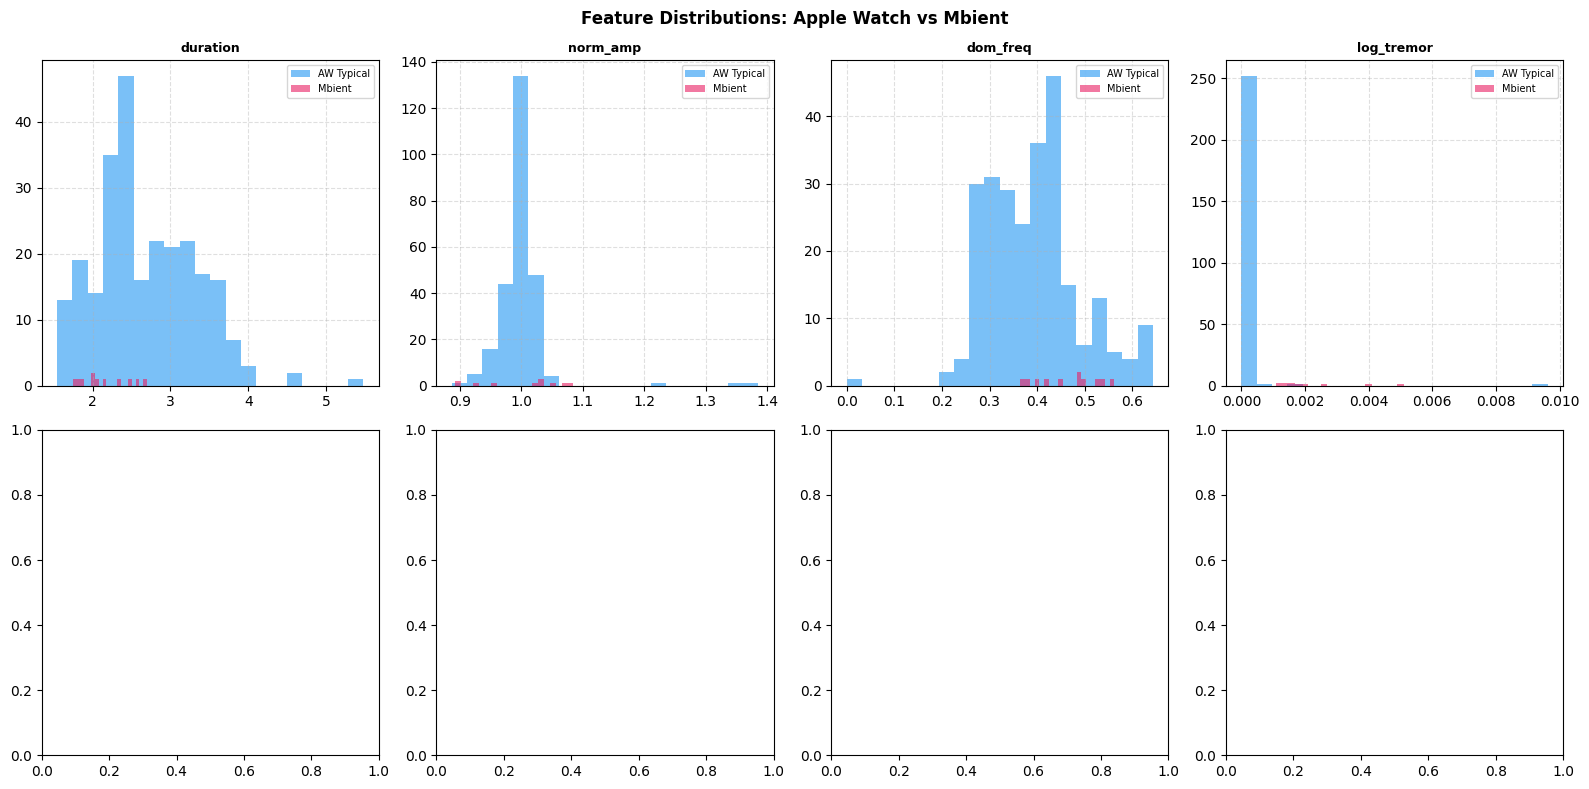


Feature means comparison:
            AW_Typical    Mbient
duration      2.680372  2.156455
norm_amp      1.000000  1.000000
dom_freq      0.392177  0.464709
log_tremor    0.000059  0.002123


In [65]:
# Compare feature distributions between Apple Watch training data and Mbient
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Feature Distributions: Apple Watch vs Mbient', fontweight='bold')

for i, feat in enumerate(FEATURE_COLS):
    ax = axes[i // 4][i % 4]
    ax.hist(df_clean[df_clean['label'] == 'Typical'][feat], 
            bins=20, alpha=0.6, color='#2196F3', label='AW Typical')
    ax.hist(df_mbient[feat], 
            bins=20, alpha=0.6, color='#E91E63', label='Mbient')
    ax.set_title(feat, fontweight='bold', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Also print means side by side
print("\nFeature means comparison:")
print(pd.DataFrame({
    'AW_Typical': df_clean[df_clean['label'] == 'Typical'][FEATURE_COLS].mean(),
    'Mbient':     df_mbient[FEATURE_COLS].mean()
}))

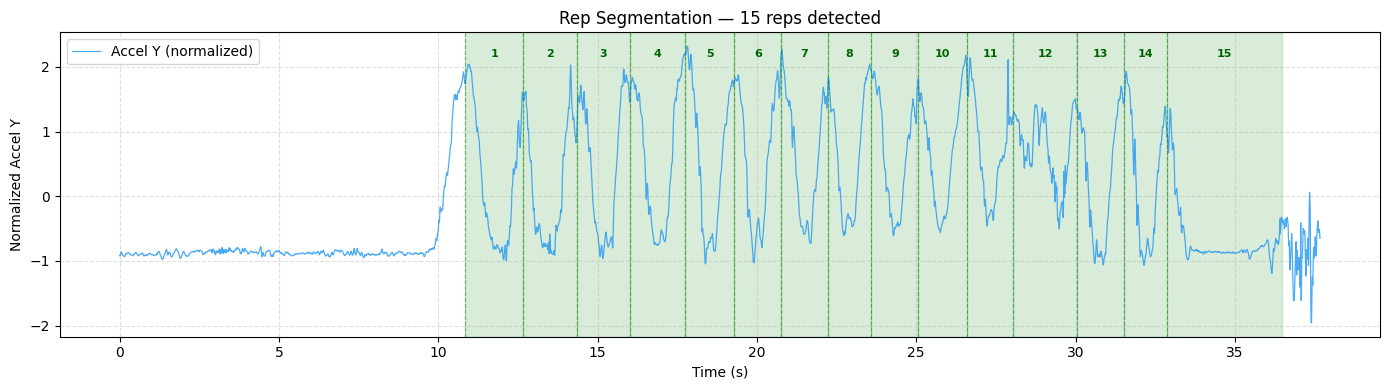

In [79]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time_mbient, sig_mbient, color='#2196F3', lw=0.9, alpha=0.8, label='Accel Y (normalized)')

for i, rep in enumerate(rep_segments):
    ax.axvspan(rep['t_start'], rep['t_end'], alpha=0.15, color='green')
    ax.axvline(rep['t_start'], color='green', lw=0.8, linestyle='--', alpha=0.5)
    ax.text(rep['t_start'] + (rep['t_end'] - rep['t_start'])/2, 
            ax.get_ylim()[1] * 0.85,
            str(i+1), ha='center', fontsize=8, color='darkgreen', fontweight='bold')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Normalized Accel Y')
ax.set_title(f'Rep Segmentation — {len(rep_segments)} reps detected')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()